# Classification Chats vs Chiens - CNN Simple

Ce notebook realise une classification binaire d'images (chat ou chien) en plusieurs etapes. Chaque etape est expliquee en detail pour comprendre ce que fait le code et pourquoi.

##Etape 0.1 : Connection avec Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Etape 1 : Import des bibliotheques et configuration

On importe les modules Python necessaires et on definit les parametres globaux. Ces variables determinent le chemin des donnees, la taille des images, et combien d'images charger par classe.

In [2]:
# Bibliotheques pour le calcul numerique (numpy), l'apprentissage profond (tensorflow/keras),
# les graphiques (matplotlib), et la manipulation de fichiers (pathlib, zipfile, PIL)
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
from PIL import Image

# Configuration : chemin du fichier zip contenant les images
#ZIP_PATH = 'kagglecatsanddogs_5340.zip'
# Updated ZIP_PATH points to the file in Google Drive
ZIP_PATH = '/content/drive/MyDrive/AI_class/kagglecatsanddogs_5340.zip'
# Dossier ou extraire les images
DATA_DIR = 'cats_dogs_data'
# Taille cible des images en pixels (largeur et hauteur). Toutes les images seront redimensionnees
# a 128x128 pour que le modele ait des entrees de taille fixe
IMG_SIZE = 128
# Nombre max d'images a charger par classe (Chat et Chien). Limiter reduit le temps d'entrainement
# mais moins de donnees peut diminuer la precision. Augmenter a 5000+ pour de meilleurs resultats
MAX_IMAGES_PER_CLASS = 2000

##Etape 1.1 : Verification de GPU

In [3]:
#import tensorflow as tf
print("GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")

GPUs Available:  1
Default GPU Device: /device:GPU:0


## Etape 2 : Extraction et chargement des donnees

On extrait le fichier zip si necessaire, puis on charge les images. Chaque image est convertie en RGB et redimensionnee. Les etiquettes (labels) : 0 pour Chat, 1 pour Chien.

In [4]:
def load_cats_dogs(zip_path=ZIP_PATH, data_dir=DATA_DIR, img_size=IMG_SIZE, max_per_class=MAX_IMAGES_PER_CLASS):
    """
    Extrait le zip et charge les images de chats et chiens.
    Retourne X (tableau d'images) et y (etiquettes : 0=Chat, 1=Chien).
    """
    # Extraire le zip uniquement si le dossier de donnees n'existe pas encore
    if Path(data_dir).exists() is False:
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(data_dir)

    base = Path(data_dir) / 'PetImages'
    X, y = [], []
    for label, folder in enumerate(['Cat', 'Dog']):  # label 0 = Chat, 1 = Chien
        folder_path = base / folder
        if not folder_path.exists():
            continue
        count = 0
        for img_path in sorted(folder_path.glob('*.jpg')):
            if count >= max_per_class:
                break
            try:
                img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
                X.append(np.array(img))  # Conversion PIL -> numpy
                y.append(label)
                count += 1
            except Exception:
                pass
    return np.array(X), np.array(y)

X_raw, y = load_cats_dogs()
print(f"Charge : {X_raw.shape[0]} images, forme {X_raw.shape[1:]}")
print(f"Classes : Chat=0, Chien=1 | Effectifs : Chat={np.sum(y==0)}, Chien={np.sum(y==1)}")

Charge : 4000 images, forme (128, 128, 3)
Classes : Chat=0, Chien=1 | Effectifs : Chat=2000, Chien=2000


## Etape 3 : Visualisation d'exemples d'images

On affiche 10 images (5 chats, 5 chiens) pour verifier que le chargement s'est bien passe et voir a quoi ressemblent les donnees.

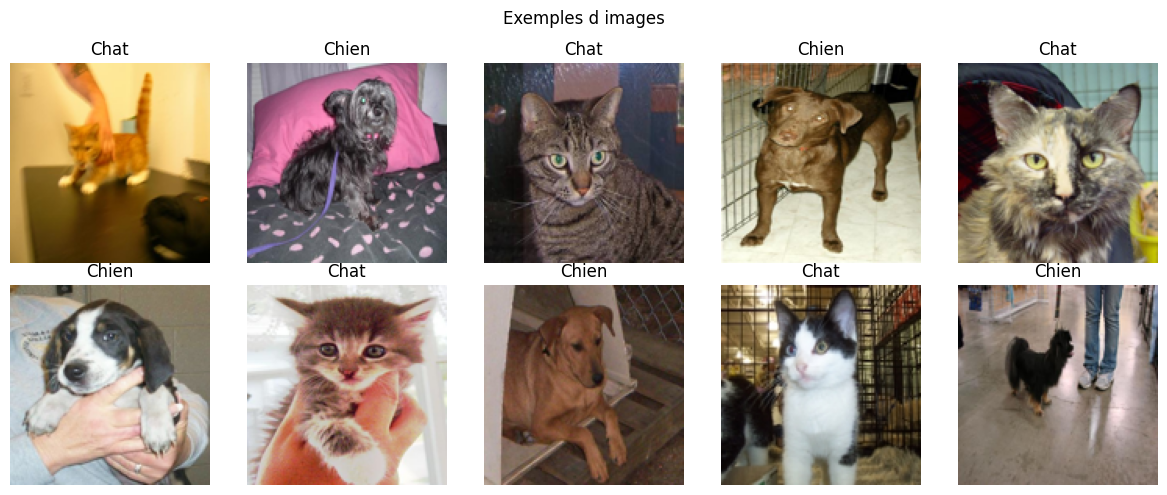

In [ ]:
# Creer une grille 2 lignes x 5 colonnes pour afficher 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # i % 2 donne 0 ou 1 (alternance Chat/Chien), i // 2 donne l'indice dans la classe
    idx = np.where(y == i % 2)[0][i // 2]
    ax.imshow(X_raw[idx])
    ax.set_title('Chat' if y[idx] == 0 else 'Chien')
    ax.axis('off')
plt.suptitle('Exemples d images', fontsize=12)
plt.tight_layout()
plt.show()

## Etape 4 : Pre-traitement - Normalisation des pixels

Les pixels bruts sont des entiers entre 0 et 255. On les divise par 255 pour obtenir des valeurs entre 0 et 1. Cela stabilise l'entrainement du reseau de neurones : des valeurs trop grandes peuvent faire diverger les poids.

In [5]:
# Conversion en float et normalisation : valeurs de pixels entre 0 et 1
X = X_raw.astype(np.float32) / 255.0
print(f"Plage des pixels apres normalisation : [{X.min():.2f}, {X.max():.2f}]")

Plage des pixels apres normalisation : [0.00, 1.00]


## Etape 5 : Division train / validation / test

On separe les donnees en trois ensembles :
- **Train** : pour entrainer le modele (le modele apprend sur ces images)
- **Validation** : pour suivre la performance pendant l'entrainement et arreter au bon moment (eviter l'overfitting)
- **Test** : pour evaluer le modele a la fin sur des images jamais vues

stratify=y garantit que la proportion Chat/Chien reste la meme dans chaque ensemble. random_state=42 assure la reproductibilite.

In [6]:
from sklearn.model_selection import train_test_split

# D'abord isoler 15% pour le test (donnees jamais vues jusqu'a la fin)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
# Puis diviser le reste : 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

Train : 2720 | Val : 680 | Test : 600


## Etape 6 : Construction du modele CNN

Un CNN (Reseau de Neurones Convolutionnel) est adapte aux images. Structure :
- **Conv2D** : detecte des motifs locaux (bords, textures)
- **MaxPool2D** : reduit la taille spatiale, garde les caracteristiques les plus fortes
- **Flatten** : aplatit en une ligne pour les couches denses
- **Dense** : neurones classiques pour la decision finale
- **Dropout** : desactive aleatoirement 50% des neurones a chaque pas pour eviter l'overfitting
- **sigmoid** : sortie entre 0 et 1 (probabilite "Chien"). > 0.5 = Chien, <= 0.5 = Chat

**Parametres a experimenter :** IMG_SIZE (plus grand = plus de details), nombre de filtres Conv2D (32/64/128), Dense(128), Dropout(0.5), learning_rate(0.001). Voir commentaires dans le code.

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),  # ASTUCE: IMG_SIZE plus grand = plus de details
    keras.layers.Conv2D(32, 3, activation='relu'),      # ASTUCE: 32 filtres -> essayer 16, 64
    keras.layers.MaxPool2D(2),                          # Reduction 2x2
    keras.layers.Conv2D(64, 3, activation='relu'),      # ASTUCE: progression 32->64->128 peut etre modifiee
    keras.layers.MaxPool2D(2),                          # ASTUCE: pool 3 pour reduction plus forte
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),                             # Conversion 2D -> 1D
    keras.layers.Dense(128, activation='relu'),         # ASTUCE: 64 ou 256 selon capacite souhaitee
    keras.layers.Dropout(0.5),                          # ASTUCE: 0.3-0.4 si sous-apprentissage, 0.6 si overfitting
    keras.layers.Dense(1, activation='sigmoid')         # Sortie binaire : probabilite Chien
])

# Compilation : on choisit la fonction de perte (binary_crossentropy pour binaire),
# l'optimiseur (Adam) et la metrique a afficher (accuracy)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # ASTUCE: 0.0005 si instable, 0.002 si trop lent
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Etape 7 : Augmentation des donnees et callbacks

**Augmentation** : on applique des transformations aleatoires (rotation, decalage, zoom, retournement) pour creer des variantes des images d'entrainement. Cela aide le modele a generaliser et evite l'overfitting.

**aug_generator** : genere des lots d'images augmentees indefiniment (Keras exige un generateur qui ne s'epuise pas).

**EarlyStopping** : arrete l'entrainement si val_loss ne s'ameliore pas pendant 8 epochs. restore_best_weights recharge les meilleurs poids.

**ReduceLROnPlateau** : divise le learning rate par 2 si val_loss stagne pendant 4 epochs. Un LR plus bas permet un affinage fin.

**Parametres a ajuster :** rotation_range, zoom_range (augmenter si overfitting). patience de EarlyStopping (augmenter si entrainement s'arrete trop tot). batch_size (32) : plus grand = courbes plus stables mais plus de memoire.

In [7]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,          # Rotation aleatoire jusqu'a 20 degres
    width_shift_range=0.2,      # Decalage horizontal jusqu'a 20% de la largeur
    height_shift_range=0.2,     # Decalage vertical jusqu'a 20% de la hauteur
    horizontal_flip=True,       # Retournement horizontal aleatoire (chat/chien symetriques)
    zoom_range=0.2,             # Zoom aleatoire entre 80% et 120%
    fill_mode='nearest'         # Comment remplir les pixels hors image
)

def aug_generator():
    while True:
        for xb, yb in datagen.flow(X_train, y_train, batch_size=32, shuffle=True):
            yield xb, yb

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)  # factor=0.5 : divise LR par 2 ; patience=4 : attend 4 epochs sans amelioration

## Etape 8 : Entrainement du modele

model.fit lance l'entrainement. steps_per_epoch = nombre de lots par epoch. validation_data permet de calculer val_loss et val_accuracy a chaque epoch. Les callbacks (early_stop, reduce_lr) sont appliques automatiquement.

In [ ]:
# history contient loss, accuracy, val_loss, val_accuracy pour chaque epoch
history = model.fit(
    aug_generator(),
    steps_per_epoch=max(1, len(X_train) // 32),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.5162 - loss: 0.7061 - val_accuracy: 0.5044 - val_loss: 0.6896 - learning_rate: 0.0010
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.5342 - loss: 0.6890 - val_accuracy: 0.5426 - val_loss: 0.6824 - learning_rate: 0.0010
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.5875 - loss: 0.6731 - val_accuracy: 0.5868 - val_loss: 0.6657 - learning_rate: 0.0010
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.6022 - loss: 0.6661 - val_accuracy: 0.5853 - val_loss: 0.6631 - learning_rate: 0.0010
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.6158 - loss: 0.6561 - val_accuracy: 0.6618 - val_loss: 0.6392 - learning_rate: 0.0010
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.6401 - loss: 0.6321 - val_accuracy: 0.6706 - val_loss: 0.6174 - learning_rate: 0.0010
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.6467 - loss: 0.

## Etape 9 : Graphiques de la perte et de la precision

**Variables des graphiques :**
- **Axe X (Epoch)** : numero du passage complet sur les donnees d'entrainement
- **loss (perte train)** : erreur sur les images d'entrainement. On veut qu'elle diminue
- **val_loss (perte validation)** : erreur sur les images de validation. On veut qu'elle diminue et suive la loss
- **accuracy** : pourcentage de bonnes reponses sur le train
- **val_accuracy** : pourcentage de bonnes reponses sur la validation

**Signes d'overfitting a surveiller :**
- loss continue de baisser alors que val_loss remonte ou stagne
- accuracy monte alors que val_accuracy stagne ou baisse
- Un ecart croissant entre les courbes train et validation indique que le modele memorise le train au lieu de generaliser

**Bon equilibre :** les deux courbes (train et validation) evoluent ensemble, val_loss reste proche de loss, val_accuracy suit accuracy.

**Conseils selon ce que vous observez :**
- val_loss remonte (overfitting) : augmenter Dropout, reduire les couches/neurones, plus d'augmentation
- Les deux courbes restent hautes (sous-apprentissage) : plus d'epochs, modele plus complexe, learning_rate plus eleve
- Courbes tres irregulieres : reduire learning_rate, augmenter batch_size

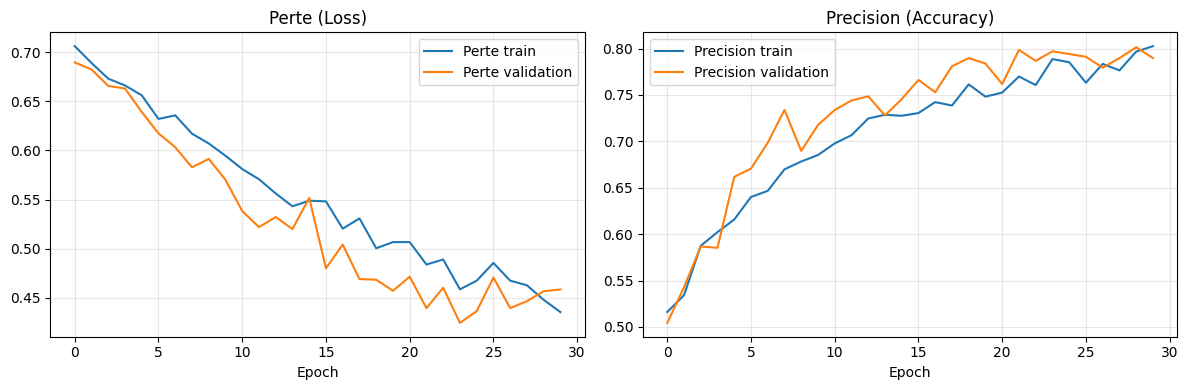

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history.history['loss'], label='Perte train')
axes[0].plot(history.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history.history['accuracy'], label='Precision train')
axes[1].plot(history.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Etape 10 : Evaluation sur le jeu de test

On evalue le modele sur des images jamais vues (test set). C'est la mesure finale de la qualite. Un ecart modere entre precision train et test est normal. Un ecart tres grand indique de l'overfitting.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nPrecision sur le jeu de test : {test_acc*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7800 - loss: 0.4831

Precision sur le jeu de test : 78.00%


**Rapport de classification - Definitions :**
- **Precision** : parmi les images predites comme Chien (ou Chat), combien sont reellement des Chiens (ou Chats). Precision haute = peu de faux positifs.
- **Recall (Rappel)** : parmi les vrais Chiens (ou Chats), combien ont ete correctement identifies. Recall haut = peu de faux negatifs.
- **F1-score** : moyenne harmonique de precision et recall. Metrique globale pour une classe.
- **Support** : nombre d'exemples reels dans le test pour chaque classe.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# predict donne une probabilite ; > 0.5 signifie prediction Chien (1), sinon Chat (0)
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Chat', 'Chien']))
# Matrice de confusion : lignes = vraie etiquette, colonnes = prediction
# [[vrais Chats predits Chat, vrais Chats predits Chien], [vrais Chiens predits Chat, vrais Chiens predits Chien]]
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Rapport de classification :
              precision    recall  f1-score   support

        Chat       0.78      0.79      0.78       300
       Chien       0.78      0.77      0.78       300

    accuracy                           0.78       600
   macro avg       0.78      0.78      0.78       600
weighted avg       0.78      0.78      0.78       600

Matrice de confusion :
[[236  64]
 [ 68 232]]


## Etape 11 : Sauvegarde du modele

Sauvegarder le modele permet de le reutiliser plus tard sans le reentrainer (chargement avec keras.models.load_model).

In [ ]:
model.save('cats_dogs_model.keras')
print('Modele sauvegarde dans cats_dogs_model.keras')

---

# Partie 1 — Modifications et expériences



# Expérience 1 : Augmentation de la taille du jeu de données (Suggestion E)

**Changement :** Augmentation du nombre d'images chargées de 2 000 à 4 000 par classe (8 000 images au total), en gardant exactement la même architecture et les mêmes paramètres que le modèle de base..

**Pourquoi :** Plus un modèle voit d'exemples variés, plus il a de chances d'apprendre des caractéristiques générales plutôt que de mémoriser le jeu d'entraînement. Avec seulement 2 000 images par classe, le modèle peut être limité par la quantité d'information disponible. Doubler ce nombre expose le réseau à davantage de variations (poses, éclairages, races différentes) ce qui devrait améliorer sa capacité à bien classer des images inconnues.

**Observation: :** La précision sur le jeu de test est passée de 78,00 % à 84,00 %, soit un gain de +6 points. En contrepartie, le temps d'entraînement a doublé (d'environ 7 minutes à 14 minutes), ce qui est logique puisqu'il y a deux fois plus de données à traiter à chaque époque. Ce résultat confirme que la quantité de données a un impact direct et positif sur la performance, au prix d'un temps de calcul plus long.

In [9]:
# 1. Charger 4000 images par classe
X_raw_exp1, y_exp1 = load_cats_dogs(max_per_class=4000)
print(f"Nouvelle charge : {X_raw_exp1.shape[0]} images")

# 2. Normalisation
X_exp1 = X_raw_exp1.astype(np.float32) / 255.0

# 3. Division train / validation / test
X_train_e1, X_test_e1, y_train_e1, y_test_e1 = train_test_split(X_exp1, y_exp1, test_size=0.15, stratify=y_exp1, random_state=42)
X_train_e1, X_val_e1, y_train_e1, y_val_e1 = train_test_split(X_train_e1, y_train_e1, test_size=0.2, stratify=y_train_e1, random_state=42)

print(f"Nouveaux ensembles -> Train : {len(X_train_e1)} | Val : {len(X_val_e1)} | Test : {len(X_test_e1)}")

Nouvelle charge : 8000 images
Nouveaux ensembles -> Train : 5440 | Val : 1360 | Test : 1200


In [ ]:
# 4. Re-créer le modèle de base (pour repartir de zéro)
model_exp1 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model_exp1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# 5. Entraîner le modèle
history_exp1 = model_exp1.fit(
    datagen.flow(X_train_e1, y_train_e1, batch_size=32, shuffle=True), # Générateur avec les nouvelles données
    steps_per_epoch=max(1, len(X_train_e1) // 32),
    epochs=30,
    validation_data=(X_val_e1, y_val_e1),
    callbacks=[early_stop, reduce_lr]
)

# 6. Évaluer sur le nouveau jeu de test
test_loss_e1, test_acc_e1 = model_exp1.evaluate(X_test_e1, y_test_e1)
print(f"\nPrécision finale (Exp 1) : {test_acc_e1*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.5222 - loss: 0.7022 - val_accuracy: 0.6419 - val_loss: 0.6414 - learning_rate: 0.0010
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.5920 - loss: 0.6749 - val_accuracy: 0.6478 - val_loss: 0.6190 - learning_rate: 0.0010
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.6183 - loss: 0.6585 - val_accuracy: 0.6926 - val_loss: 0.6069 - learning_rate: 0.0010
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.6026 - loss: 0.6580 - val_accuracy: 0.6625 - val_loss: 0.6066 - learning_rate: 0.0010
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.6535 - loss: 0.6346 - val_accuracy: 0.7000 - val_loss: 0.5810 - learning_rate: 0.0010
Epoch 6/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.6526 - loss: 0.6271 - val_accuracy: 0.7228 - val_loss: 0.5599 - learning_rate: 0.0010
Epoch 7/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - accuracy: 0.6

## Graphique de l'expérience 1

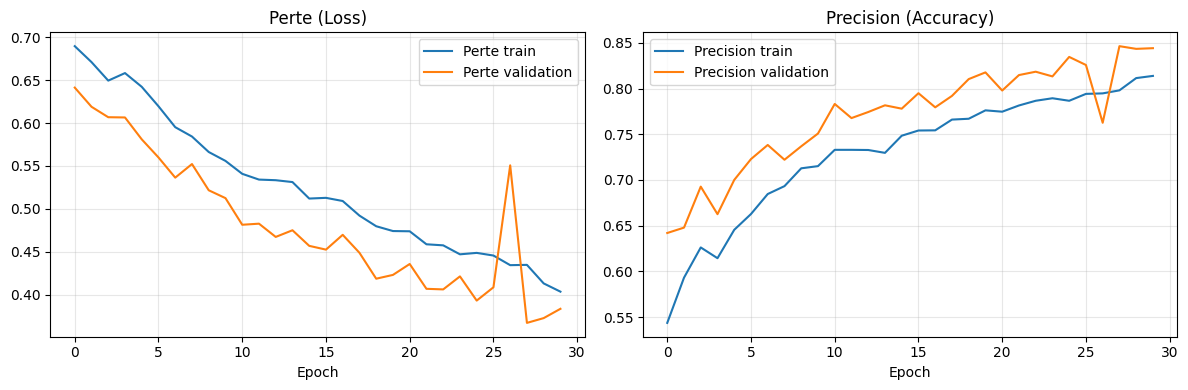

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history_exp1.history['loss'], label='Perte train')
axes[0].plot(history_exp1.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history_exp1.history['accuracy'], label='Precision train')
axes[1].plot(history_exp1.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Expérience 2 : Architecture plus profonde (Suggestion C)

**Changement :** Ajout d'une quatrième couche de convolution Conv2D(256 filtres) suivie d'un MaxPool2D(2), en conservant le jeu de données étendu à 4 000 images par classe de l'Expérience 1.

**Pourquoi :** Le modèle de base avec 3 couches extrait des caractéristiques visuelles de complexité limitée. En ajoutant une quatrième couche avec 256 filtres, on donne au réseau la capacité de détecter des motifs visuels plus abstraits et plus. Plus le réseau est profond, plus les caractéristiques qu'il peut apprendre sont sophistiquées.

**Observations :** La précision a encore progressé, atteignant 87,25 % (+3,25 points par rapport à l'Expérience 1). Le temps d'entraînement est resté pratiquement identique (~14 minutes), car le nombre d'images n'a pas changé. L'ajout d'une seule couche supplémentaire a donc apporté un gain significatif sans coût computationnel additionnel visible. Ce résultat montre que l'architecture a encore de la marge pour s'améliorer.

In [ ]:
# 1. Création du modèle plus profond
model_exp2 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.MaxPool2D(2),

    # --- LA NOUVELLE COUCHE ---
    keras.layers.Conv2D(256, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    # --------------------------

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model_exp2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# 2. Entraînement en réutilisant les données de l'Expérience 1
history_exp2 = model_exp2.fit(
    datagen.flow(X_train_e1, y_train_e1, batch_size=32, shuffle=True),
    steps_per_epoch=max(1, len(X_train_e1) // 32),
    epochs=30,
    validation_data=(X_val_e1, y_val_e1),
    callbacks=[early_stop, reduce_lr]
)

# 3. Évaluation
test_loss_e2, test_acc_e2 = model_exp2.evaluate(X_test_e1, y_test_e1)
print(f"\nPrécision finale (Exp 2) : {test_acc_e2*100:.2f}%")

Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 32s 155ms/step - accuracy: 0.5111 - loss: 0.6963 - val_accuracy: 0.5015 - val_loss: 0.7049 - learning_rate: 0.0010
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - accuracy: 0.5406 - loss: 0.6853 - val_accuracy: 0.5890 - val_loss: 0.6662 - learning_rate: 0.0010
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.5779 - loss: 0.6673 - val_accuracy: 0.6662 - val_loss: 0.6129 - learning_rate: 0.0010
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 149ms/step - accuracy: 0.6076 - loss: 0.6590 - val_accuracy: 0.6632 - val_loss: 0.6125 - learning_rate: 0.0010
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.6385 - loss: 0.6389 - val_accuracy: 0.6919 - val_loss: 0.6032 - learning_rate: 0.0010
Epoch 6/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.6660 - loss: 0.6087 - val_accuracy: 0.6904 - val_loss: 0.5915 - learning_rate: 0.0010
Epoch 7/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.6

## Graphique de l'expérience 2

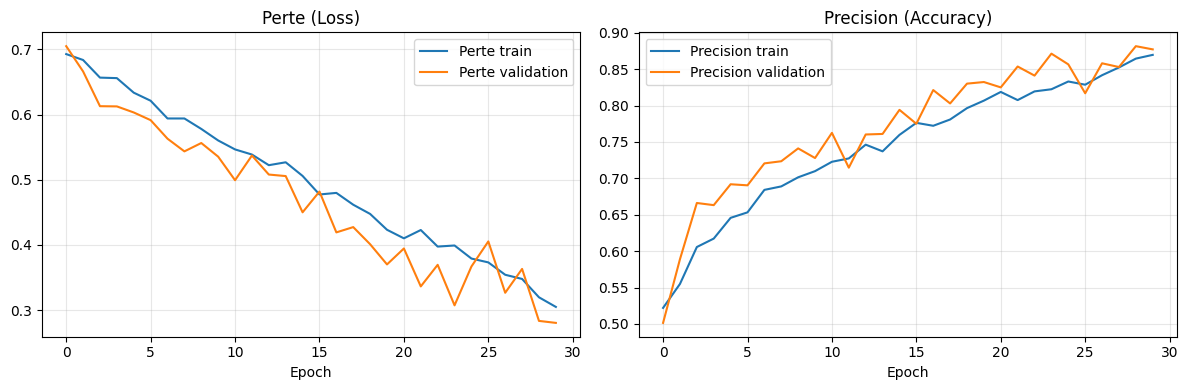

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history_exp2.history['loss'], label='Perte train')
axes[0].plot(history_exp2.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history_exp2.history['accuracy'], label='Precision train')
axes[1].plot(history_exp2.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Expérience 3 : Taux d'apprentissage (Learning Rate) réduit (Suggestion B)

**Changement :** Réduction du taux d'apprentissage de 0.001 à 0.0005, en conservant l'architecture à 4 couches de l'Expérience 2 et les 4 000 images par classe.

**Pourquoi :** Je voulais vérifier si un taux d'apprentissage plus petit permettrait au modèle de converger vers une meilleure solution en faisant des ajustements de poids plus fins et plus prudents. C'est une modification souvent recommandée pour les réseaux plus profonds, car ils sont potentiellement plus sensibles aux grands sauts pendant l'optimisation. .

**Observations :** La précision a légèrement diminué à 85,17 % (soit -2,08 points par rapport à l'Expérience 2). En pratique, le modèle dispose déjà du callback ReduceLROnPlateau qui réduit automatiquement le taux d'apprentissage dès qu'il détecte que la progression stagne. Fixer manuellement un taux plus bas dès le départ ralentit l'apprentissage initial sans apporter de bénéfice supplémentaire sur ce jeu de données. Le taux de 0.001 est donc un meilleur point de départ pour cette configuration.

In [ ]:
# --- EXPERIMENT 3: Learning Rate = 0.0005 ---
print("--- Démarrage Expérience 3 : Learning Rate 0.0005 ---")

# 1. On garde la même architecture profonde que l'Expérience 2
model_exp3 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(256, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

# 2. MODIFICATION : Le learning_rate passe de 0.001 à 0.0005
model_exp3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Entraînement en utilisant les données étendues (e1)
history_exp3 = model_exp3.fit(
    datagen.flow(X_train_e1, y_train_e1, batch_size=32, shuffle=True),
    steps_per_epoch=max(1, len(X_train_e1) // 32),
    epochs=30,
    validation_data=(X_val_e1, y_val_e1),
    callbacks=[early_stop, reduce_lr]
)

# 4. Évaluation sur le jeu de test
test_loss_e3, test_acc_e3 = model_exp3.evaluate(X_test_e1, y_test_e1)
print(f"\nPrécision finale (Exp 3) : {test_acc_e3*100:.2f}%")

--- Démarrage Expérience 3 : Learning Rate 0.0005 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 36s 164ms/step - accuracy: 0.4922 - loss: 0.6954 - val_accuracy: 0.5074 - val_loss: 0.6838 - learning_rate: 5.0000e-04
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.5558 - loss: 0.6881 - val_accuracy: 0.5588 - val_loss: 0.6790 - learning_rate: 5.0000e-04
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - accuracy: 0.5894 - loss: 0.6670 - val_accuracy: 0.6522 - val_loss: 0.6433 - learning_rate: 5.0000e-04
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.6194 - loss: 0.6518 - val_accuracy: 0.6618 - val_loss: 0.6316 - learning_rate: 5.0000e-04
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 149ms/step - accuracy: 0.6454 - loss: 0.6247 - val_accuracy: 0.6706 - val_loss: 0.6104 - learning_rate: 5.0000e-04
Epoch 6/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - accuracy: 0.6933 - loss: 0.5902 - val_accuracy: 0.6949 - val_loss: 0.5855 - learning_rate: 5.0000e-04
Epoch 7/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 14

## Graphique de l'expérience 3

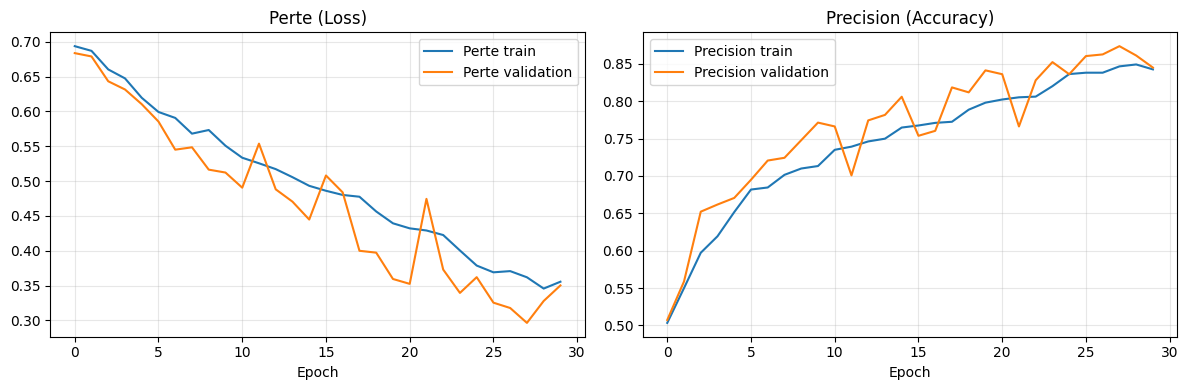

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history_exp3.history['loss'], label='Perte train')
axes[0].plot(history_exp3.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history_exp3.history['accuracy'], label='Precision train')
axes[1].plot(history_exp3.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Expérience 4 : Taux de Dropout réduit à 0.3 (Suggestion D)

**:Changement :** Réduction du taux de Dropout de 0.5 à 0.3, en revenant au taux d'apprentissage de 0.001 et en conservant l'architecture à 4 couches de l'Expérience 2.

**Pourquoi :** Dans l'Expérience 2, les courbes d'entraînement et de validation restaient assez proches, ce qui suggère que le Dropout à 0.5 (qui désactive aléatoirement 50 % des neurones) était peut-être trop restrictif. Un Dropout plus faible à 0.3 laisse plus de neurones actifs à chaque étape, ce qui pourrait permettre au modèle de mieux mémoriser les caractéristiques importantes et ainsi améliorer la précision..

**Observations :** La précision atteint 85,92 %, ce qui est légèrement inférieur aux 87,25 % de l'Expérience 2. On observe également un écart plus marqué entre la précision d'entraînement et de validation, signe que le modèle commence à légèrement sur-apprendre. Cela confirme que le Dropout à 0.5 était en réalité bien calibré pour cette architecture : le réduire permet d'apprendre un peu plus vite mais au prix d'une moindre capacité à généraliser.

In [ ]:
# --- EXPERIMENT 4: Dropout = 0.3 ---
print("--- Démarrage Expérience 4 : Dropout 0.3 ---")

model_exp4 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(256, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    # MODIFICATION: Dropout passe de 0.5 à 0.3
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_exp4.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history_exp4 = model_exp4.fit(
    datagen.flow(X_train_e1, y_train_e1, batch_size=32, shuffle=True),
    steps_per_epoch=max(1, len(X_train_e1) // 32),
    epochs=30,
    validation_data=(X_val_e1, y_val_e1),
    callbacks=[early_stop, reduce_lr]
)

test_loss_e4, test_acc_e4 = model_exp4.evaluate(X_test_e1, y_test_e1)
print(f"\nPrécision finale (Exp 4) : {test_acc_e4*100:.2f}%")

--- Démarrage Expérience 4 : Dropout 0.3 ---
Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step - accuracy: 0.5056 - loss: 0.6950 - val_accuracy: 0.5551 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.5331 - loss: 0.6878 - val_accuracy: 0.5721 - val_loss: 0.6824 - learning_rate: 0.0010
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.5775 - loss: 0.6775 - val_accuracy: 0.5669 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - accuracy: 0.5799 - loss: 0.6776 - val_accuracy: 0.6279 - val_loss: 0.6383 - learning_rate: 0.0010
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - accuracy: 0.6378 - loss: 0.6360 - val_accuracy: 0.6684 - val_loss: 0.6064 - learning_rate: 0.0010
Epoch 6/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.6463 - loss: 0.6379 - val_accuracy: 0.6331 - val_loss: 0.6371 - learning_rate: 0.0010
Epoch 7/30
170/170 ━━━━━━

## Graphique de l'expérience 4

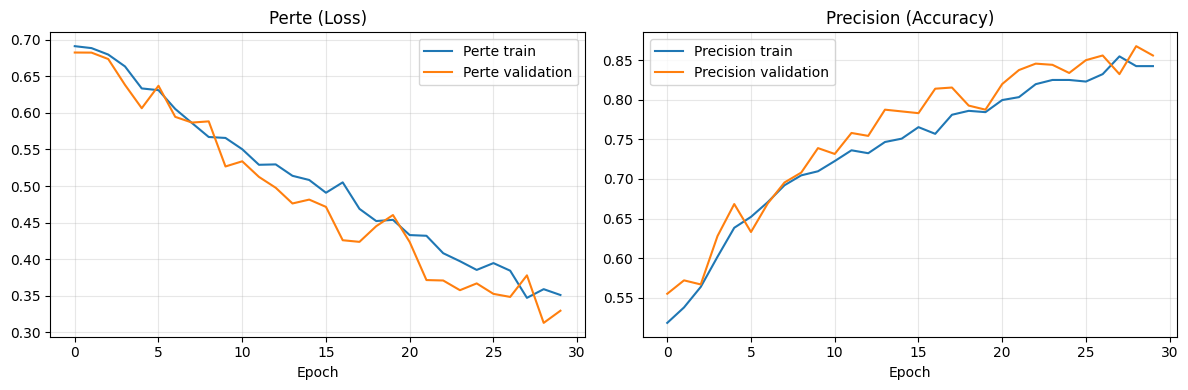

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history_exp4.history['loss'], label='Perte train')
axes[0].plot(history_exp4.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history_exp4.history['accuracy'], label='Precision train')
axes[1].plot(history_exp4.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Expérience 5 : Augmentation des données par Luminosité (Suggestion F)

**Changement**: Ajout du paramètre brightness_range=[0.7, 1.3] dans ImageDataGenerator. Les images d'entraînement sont désormais aussi modifiées aléatoirement en termes de luminosité (entre -30 % et +30 %). On revient au Dropout de 0.5 et à l'architecture de l'Expérience 2

**Pourquoi** : On voulait rendre le modèle plus robuste aux conditions d'éclairage variables. En apprenant sur des photos parfois plus sombres, parfois plus claires, le réseau devrait être moins dépendant de la luminosité pour prendre sa décision. Cela aurait dû améliorer la précision sur des images de test prises dans des conditions lumineuses différentes.

**Observation** : La précision s'est effondrée à environ 50 % — autant que si le modèle devinait au hasard. Le problème est que combiner la variation de luminosité avec toutes les autres transformations déjà présentes (rotation, zoom, décalage) rend les images d'entraînement trop difficiles à apprendre. Le modèle n'arrive plus à extraire des caractéristiques stables : il est surchargé d'exemples trop distordus. C'est un cas de sous-apprentissage (underfitting) par excès de régularisation.

In [13]:
# --- EXPERIMENT 5: Augmentation de luminosité ---
print("--- Démarrage Expérience 5 : Luminosité ---")

# MODIFICATION: Nouvel ImageDataGenerator avec brightness_range
datagen_exp5 = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3], # Ajout de la variation de luminosité
    fill_mode='nearest'
)

model_exp5 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(256, 3, activation='relu'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model_exp5.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history_exp5 = model_exp5.fit(
    datagen_exp5.flow(X_train_e1, y_train_e1, batch_size=32, shuffle=True),
    steps_per_epoch=max(1, len(X_train_e1) // 32),
    epochs=30,
    validation_data=(X_val_e1, y_val_e1),
    callbacks=[early_stop, reduce_lr]
)

test_loss_e5, test_acc_e5 = model_exp5.evaluate(X_test_e1, y_test_e1)
print(f"\nPrécision finale (Exp 5) : {test_acc_e5*100:.2f}%")

--- Démarrage Expérience 5 : Luminosité ---
Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 33s 172ms/step - accuracy: 0.4935 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 149ms/step - accuracy: 0.5135 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.4685 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 154ms/step - accuracy: 0.4964 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5035 - loss: 0.6932
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.5035 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 6/30
170/170 ━━━━━━━━━

## Graphique de l'expérience 5

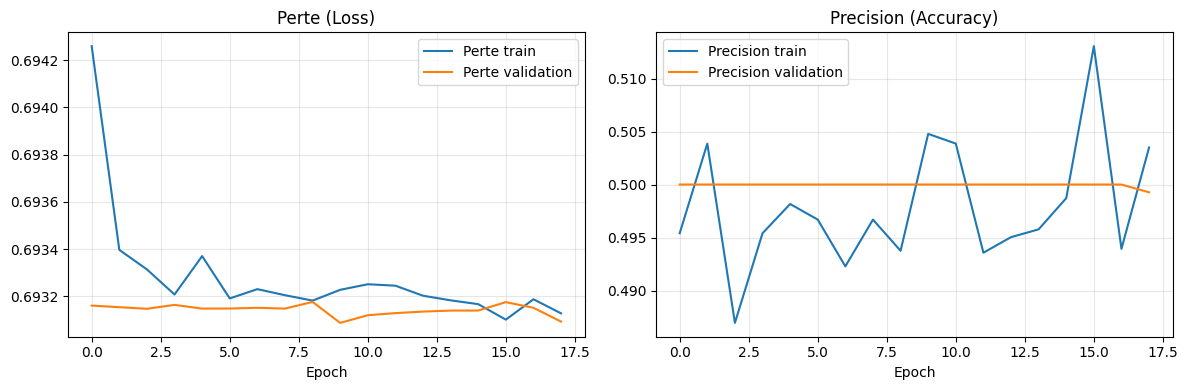

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history_exp5.history['loss'], label='Perte train')
axes[0].plot(history_exp5.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history_exp5.history['accuracy'], label='Precision train')
axes[1].plot(history_exp5.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Expérience 6 : Architecture inspirée de VGG

**Changement :** Remplacement de l'architecture séquentielle simple par une architecture inspirée du modèle VGG, avec des blocs de deux couches Conv2D successives avant chaque MaxPool2D, et une couche Dense(256) en classification. La variation de luminosité est supprimée.

**Pourquoi :** L'architecture VGG est réputée pour sa performance en vision par ordinateur. L'idée était d'extraire des caractéristiques visuelles encore plus riches grâce à cette profondeur accrue.

**Observation :** La précision stagne à nouveau à 50 %. Avec autant de couches de convolution, les signaux qui permettent d'ajuster les poids (les gradients) deviennent trop petits pour traverser tout le réseau lors de l'entraînement — c'est le problème de la disparition du gradient. Le réseau devient incapable d'apprendre. Cette expérience illustre qu'un réseau plus profond n'est pas automatiquement meilleur : il faut des techniques supplémentaires pour le stabiliser.

In [ ]:
print("--- Démarrage Expérience 6 : Architecture type VGG ---")

model_vgg = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Bloc 1
    keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    keras.layers.MaxPool2D(2),

    # Bloc 2
    keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    keras.layers.MaxPool2D(2),

    # Bloc 3
    keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    keras.layers.MaxPool2D(2),

    # Classification
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# On affiche le résumé pour voir le nombre de paramètres
model_vgg.summary()

# Entraînement en utilisant le générateur de base (sans la luminosité extrême)
history_vgg = model_vgg.fit(
    datagen.flow(X_train_e1, y_train_e1, batch_size=32, shuffle=True),
    steps_per_epoch=max(1, len(X_train_e1) // 32),
    epochs=30,
    validation_data=(X_val_e1, y_val_e1),
    callbacks=[early_stop, reduce_lr]
)

# Évaluation
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(X_test_e1, y_test_e1)
print(f"\\nPrécision finale (Exp 6 - VGG) : {test_acc_vgg*100:.2f}%")

--- Démarrage Expérience 6 : Architecture type VGG ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,676,129 (33.10 MB)

 Trainable params: 8,676,129 (33.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 44s 193ms/step - accuracy: 0.5218 - loss: 0.7110 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.5104 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 27s 158ms/step - accuracy: 0.4876 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 28s 163ms/step - accuracy: 0.5061 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.5065 - loss: 0.6932
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
170/170 ━━━━━━━━━━━━━━━━━━━━ 27s 158ms/step - accuracy: 0.5064 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 6/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 155ms/step - accuracy: 0.511

## Expérience 7 : Architecture inspirée de VGG avec Batch Normalization

**Changement :** Reprise de l'architecture VGG de l'Expérience 6, avec ajout d'une couche BatchNormalization après chaque couche de convolution et après la couche Dense(256), sans modifier les autres hyperparamètres.

**Pourquoi :** La Batch Normalization est une technique qui normalise les valeurs en sortie de chaque couche convolutive avant qu'elles ne soient transmises à la couche suivante. Cela stabilise les signaux qui circulent dans le réseau et empêche les gradients de disparaître — problème directement observé à l'Expérience 6. Sans avoir à modifier l'architecture, on peut ainsi entraîner un réseau profond de manière fiable.

**Observation :** Le résultat est spectaculaire : la précision monte à 91,67 %, soit le meilleur score obtenu parmi toutes les architectures construites depuis zéro. La Batch Normalization a bien résolu le problème de l'Expérience 6 et prouve qu'une architecture profonde fonctionne correctement à condition d'être correctement stabilisée.

In [ ]:
# --- EXPERIMENT 7 : Architecture type VGG avec Batch Normalization ---
print("--- Démarrage Expérience 7 : VGG avec Batch Normalization ---")

model_vgg = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Bloc 1
    keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    keras.layers.BatchNormalization(), # <-- STABILISATION
    keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    keras.layers.BatchNormalization(), # <-- STABILISATION
    keras.layers.MaxPool2D(2),

    # Bloc 2
    keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    keras.layers.BatchNormalization(), # <-- STABILISATION
    keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    keras.layers.BatchNormalization(), # <-- STABILISATION
    keras.layers.MaxPool2D(2),

    # Bloc 3
    keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    keras.layers.BatchNormalization(), # <-- STABILISATION
    keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    keras.layers.BatchNormalization(), # <-- STABILISATION
    keras.layers.MaxPool2D(2),

    # Classification
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(), # <-- STABILISATION
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

# On peut garder le learning rate à 0.001 car la BatchNormalization stabilise l'entraînement
model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# On affiche le résumé pour voir le nombre de paramètres et de couches
model_vgg.summary()

# Entraînement
history_vgg = model_vgg.fit(
    datagen.flow(X_train_e1, y_train_e1, batch_size=32, shuffle=True),
    steps_per_epoch=max(1, len(X_train_e1) // 32),
    epochs=30,
    validation_data=(X_val_e1, y_val_e1),
    callbacks=[early_stop, reduce_lr]
)

# Évaluation
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(X_test_e1, y_test_e1)
print(f"\nPrécision finale (Exp 7 - VGG Batch Norm) : {test_acc_vgg*100:.2f}%")

--- Démarrage Expérience 7 : VGG avec Batch Normalization ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,678,945 (33.11 MB)

 Trainable params: 8,677,537 (33.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 47s 179ms/step - accuracy: 0.5806 - loss: 0.9371 - val_accuracy: 0.5096 - val_loss: 0.7231 - learning_rate: 0.0010
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 27s 161ms/step - accuracy: 0.6337 - loss: 0.6762 - val_accuracy: 0.5559 - val_loss: 0.6959 - learning_rate: 0.0010
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.6807 - loss: 0.6199 - val_accuracy: 0.6331 - val_loss: 0.6307 - learning_rate: 0.0010
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 27s 156ms/step - accuracy: 0.6945 - loss: 0.5886 - val_accuracy: 0.7250 - val_loss: 0.5406 - learning_rate: 0.0010
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 154ms/step - accuracy: 0.7182 - loss: 0.5553 - val_accuracy: 0.7081 - val_loss: 0.5843 - learning_rate: 0.0010
Epoch 6/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 27s 160ms/step - accuracy: 0.7239 - loss: 0.5370 - val_accuracy: 0.6632 - val_loss: 0.6403 - learning_rate: 0.0010
Epoch 7/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 28s 164ms/step - accuracy: 0.7

## Graphique de l'expérience 7

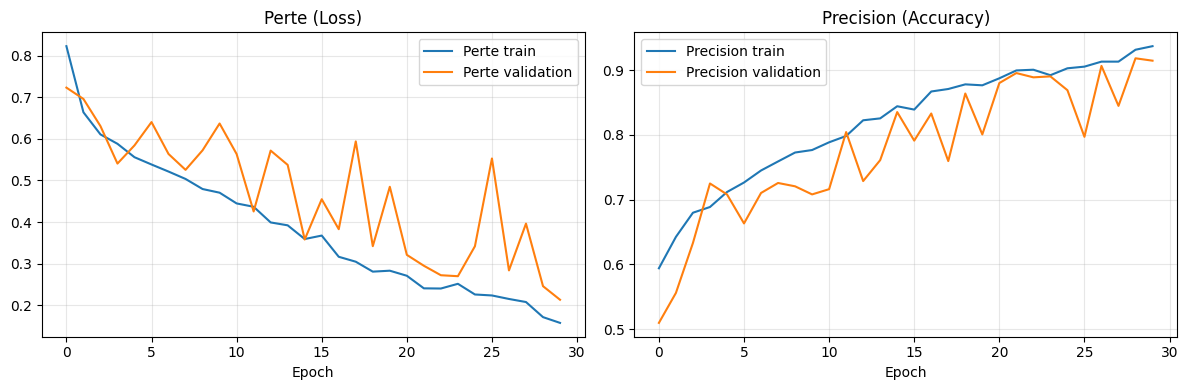

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history_vgg.history['loss'], label='Perte train')
axes[0].plot(history_vgg.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history_vgg.history['accuracy'], label='Precision train')
axes[1].plot(history_vgg.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Expérience 8 : Transfer Learning avec MobileNetV2 (Suggestion G)

**Changement :** Remplacement de l'architecture personnalisée par MobileNetV2, un modèle pré-entraîné sur des millions d'images (ImageNet). Les poids du modèle de base sont gelés (trainable=False). On ajoute uniquement GlobalAveragePooling2D, un Dropout(0.2) et une couche Dense(1, sigmoid) pour la classification. On revient aux 2 000 images par classe du jeu de données initial.

**Pourquoi :** Plutôt que d'apprendre à reconnaître des formes depuis zéro, le Transfer Learning consiste à réutiliser un modèle qui a déjà appris des millions de caractéristiques visuelles génériques (contours, textures, objets). Il suffit alors d'adapter uniquement les dernières couches au problème spécifique (chats vs. chiens), ce qui est beaucoup plus rapide et efficace que de tout entraîner de zéro.

**Observation :** La précision atteint 95,50 % — le meilleur résultat du travail, dépassant l'objectif bonus de 85 %. L'entraînement a également été très rapide (environ 4 minutes, moins que toutes les autres expériences) car seules les dernières couches sont mises à jour. Ce résultat confirme la puissance du Transfer Learning : même avec seulement 2000 images par classe (soit deux fois moins que les expériences précédentes), les performances surpassent largement tout ce qu'on a pu construire depuis zéro.

In [ ]:
# --- EXPERIMENT 8 : Transfer Learning (MobileNetV2) ---
print("--- Démarrage Expérience 8 : Transfer Learning ---")

# 1. Charger le modèle pré-entraîné MobileNetV2
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Geler le modèle de base
base_model.trainable = False

# 3. Ajouter nos propres couches de classification à la fin
model_transfer = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()

# 4. Entraînement (Utilisation de X_train et y_train au lieu de X_train_e1)
history_transfer = model_transfer.fit(
    datagen.flow(X_train, y_train, batch_size=32, shuffle=True),
    steps_per_epoch=max(1, len(X_train) // 32),
    epochs=15,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

# 5. Évaluation (Utilisation de X_test et y_test)
test_loss_transfer, test_acc_transfer = model_transfer.evaluate(X_test, y_test)
print(f"\nPrécision finale (Exp 8 - Transfer Learning) : {test_acc_transfer*100:.2f}%")





--- Démarrage Expérience 8 : Transfer Learning ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 47s 346ms/step - accuracy: 0.7348 - loss: 0.5337 - val_accuracy: 0.9235 - val_loss: 0.1810 - learning_rate: 0.0010
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 51s 142ms/step - accuracy: 0.9143 - loss: 0.2033 - val_accuracy: 0.9426 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9325 - loss: 0.1671 - val_accuracy: 0.9603 - val_loss: 0.1162 - learning_rate: 0.0010
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9262 - loss: 0.1751 - val_accuracy: 0.9426 - val_loss: 0.1304 - learning_rate: 0.0010
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9428 - loss: 0.1429 - val_accuracy: 0.9441 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.9324 - loss: 0.1627 - val_accuracy: 0.9471 - val_loss: 0.1256 - learning_rate: 0.0010
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9491 - loss: 0.1

## Graphique de l'expérience 8 - Transfer Learning

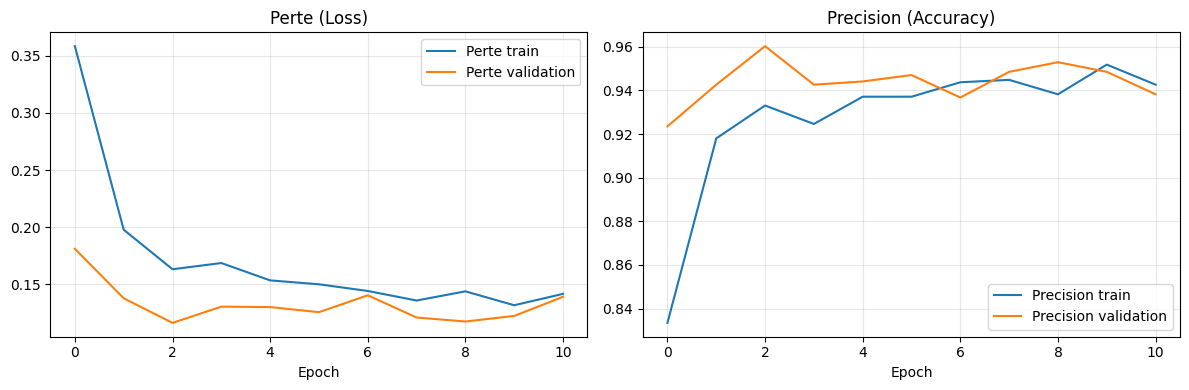

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history_transfer.history['loss'], label='Perte train')
axes[0].plot(history_transfer.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history_transfer.history['accuracy'], label='Precision train')
axes[1].plot(history_transfer.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Partie 2 — Graphiques supplémentaires

##1. Matrice de confusion visuelle (heatmap)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step


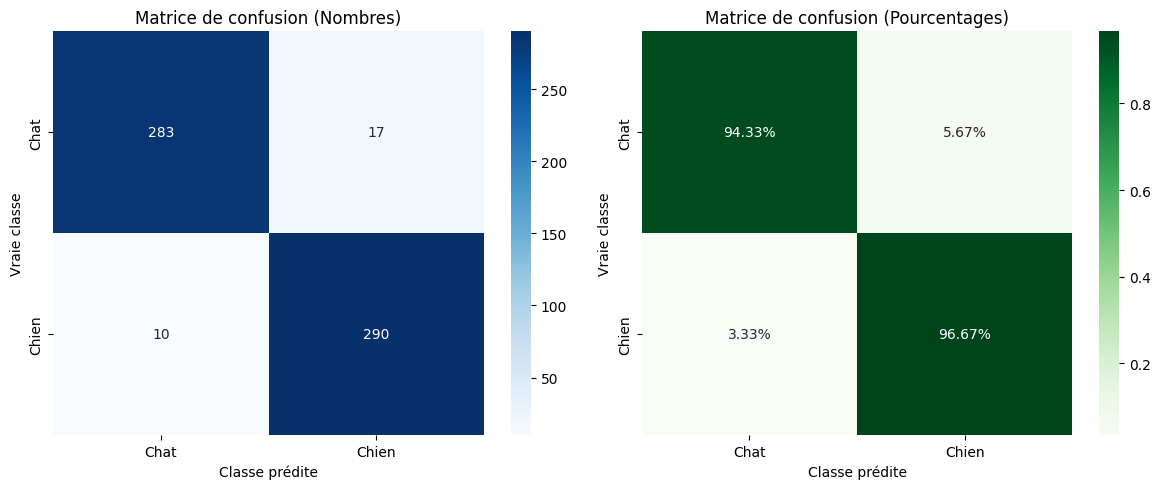

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Obtenir les probabilités prédites sur le jeu de test avec le meilleur modèle
y_pred_proba = model_transfer.predict(X_test).flatten()

# 2. Convertir les probabilités en classes (0 pour Chat, 1 pour Chien)
y_pred = (y_pred_proba > 0.5).astype(int)

# 3. Calculer la matrice de confusion classique
cm = confusion_matrix(y_test, y_pred)

# 4. Calculer la matrice en pourcentages (chaque ligne divisée par son total)
cm_perc = cm / cm.sum(axis=1, keepdims=True)

# 5. Création de l'affichage (2 graphiques côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap avec les nombres entiers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Chat', 'Chien'], yticklabels=['Chat', 'Chien'])
axes[0].set_title('Matrice de confusion (Nombres)')
axes[0].set_ylabel('Vraie classe')
axes[0].set_xlabel('Classe prédite')

# Heatmap avec les pourcentages
sns.heatmap(cm_perc, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Chat', 'Chien'], yticklabels=['Chat', 'Chien'])
axes[1].set_title('Matrice de confusion (Pourcentages)')
axes[1].set_ylabel('Vraie classe')
axes[1].set_xlabel('Classe prédite')

plt.tight_layout()
plt.show()

La matrice de confusion nous montre que le modèle Transfer Learning performe très bien globalement. On observe 94,33% de bonnes prédictions pour les chats et 96,67% pour les chiens.

##2. Distribution de confiance du modèle

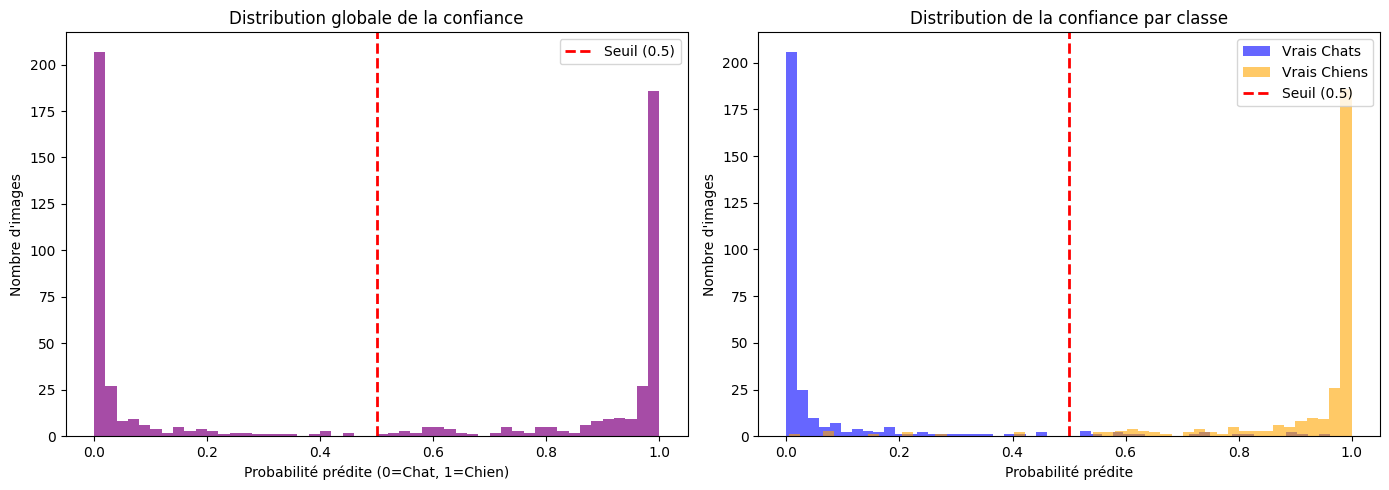

In [ ]:
import matplotlib.pyplot as plt

# Séparer les probabilités selon la vraie classe (0 pour Chat, 1 pour Chien)
prob_chats = y_pred_proba[y_test == 0]
prob_chiens = y_pred_proba[y_test == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogramme global
axes[0].hist(y_pred_proba, bins=50, color='purple', alpha=0.7)
axes[0].axvline(0.5, color='red', linestyle='dashed', linewidth=2, label='Seuil (0.5)')
axes[0].set_title('Distribution globale de la confiance')
axes[0].set_xlabel('Probabilité prédite (0=Chat, 1=Chien)')
axes[0].set_ylabel('Nombre d\'images')
axes[0].legend()

# 2. Histogramme séparé par classe
axes[1].hist(prob_chats, bins=50, color='blue', alpha=0.6, label='Vrais Chats')
axes[1].hist(prob_chiens, bins=50, color='orange', alpha=0.6, label='Vrais Chiens')
axes[1].axvline(0.5, color='red', linestyle='dashed', linewidth=2, label='Seuil (0.5)')
axes[1].set_title('Distribution de la confiance par classe')
axes[1].set_xlabel('Probabilité prédite')
axes[1].set_ylabel('Nombre d\'images')
axes[1].legend()

plt.tight_layout()
plt.show()

Le modèle Transfer Learning sépare très nettement les deux classes. Les probabilités sont massivement concentrées aux extrêmes (vers 0 et vers 1), ce qui prouve que le modèle est très confiant dans ses prédictions et hésite très peu.

##3. Comparaison des expériences

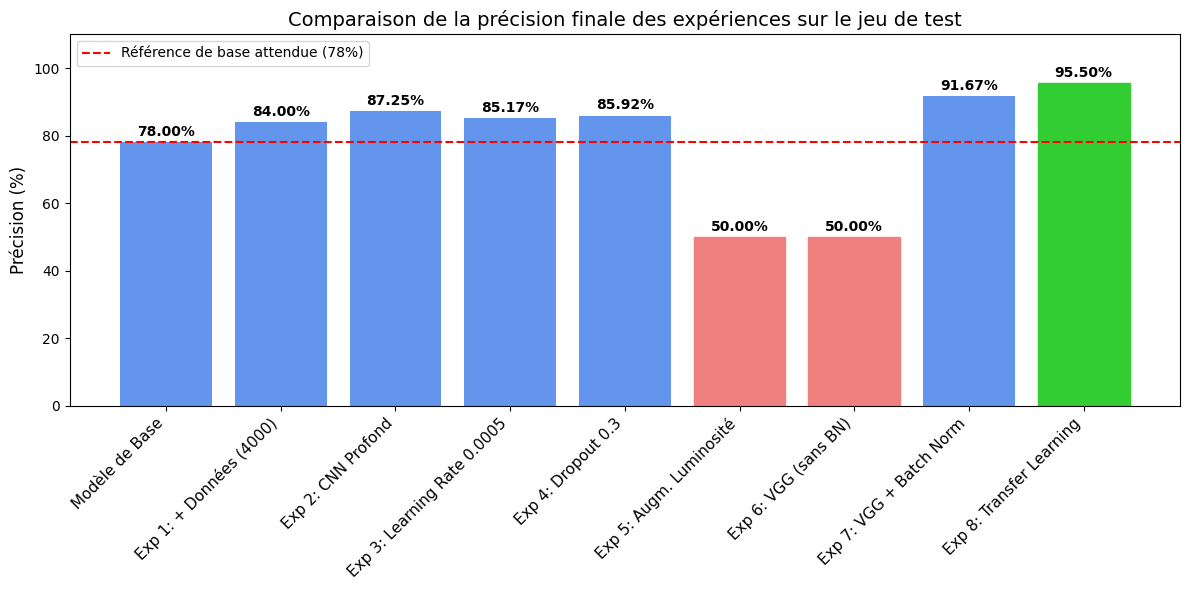

In [ ]:
import matplotlib.pyplot as plt

# Création d'un dictionnaire avec le nom de nos expériences et les précisions obtenues
# (Valeurs extraites des résultats de nos cellules précédentes)
accuracies = {
    "Modèle de Base": 78.00,
    "Exp 1: + Données (4000)": 84.00,
    "Exp 2: CNN Profond": 87.25,
    "Exp 3: Learning Rate 0.0005": 85.17,
    "Exp 4: Dropout 0.3": 85.92,
    "Exp 5: Augm. Luminosité": 50.00,
    "Exp 6: VGG (sans BN)": 50.00,
    "Exp 7: VGG + Batch Norm": 91.67,
    "Exp 8: Transfer Learning": 95.50
}

noms = list(accuracies.keys())
scores = list(accuracies.values())

# Création du graphique à barres
plt.figure(figsize=(12, 6))
bars = plt.bar(noms, scores, color='cornflowerblue')

# Mettre en évidence la meilleure expérience (en vert) et la pire (en rouge)
bars[8].set_color('limegreen') # Transfer Learning
bars[5].set_color('lightcoral') # Luminosité
bars[6].set_color('lightcoral') # VGG sans BN

# Ajouter une ligne de référence pour le score du modèle de base (78%)
plt.axhline(y=78.0, color='red', linestyle='--', label='Référence de base attendue (78%)')

# Ajouter le texte des pourcentages au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Comparaison de la précision finale des expériences sur le jeu de test', fontsize=14)
plt.ylabel('Précision (%)', fontsize=12)
plt.ylim(0, 110) # L'axe Y va jusqu'à 110 pour laisser de la place aux étiquettes
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.legend()

plt.tight_layout()
plt.show()

Comme le montre le graphique récapitulatif, la meilleure configuration trouvée est sans conteste le Transfer Learning (Exp 8) avec 95% de précision, ce qui valide la puissance des modèles pré-entraînés. On note également le succès de la Batch Normalization (Exp 7) qui a sauvé l'architecture VGG d'un effondrement total du gradient (Exp 6). À l'inverse, l'ajout extrême d'augmentation de données (Luminosité - Exp 5) a causé un sous-apprentissage massif.

##4. Evolution du taux d’apprentissage

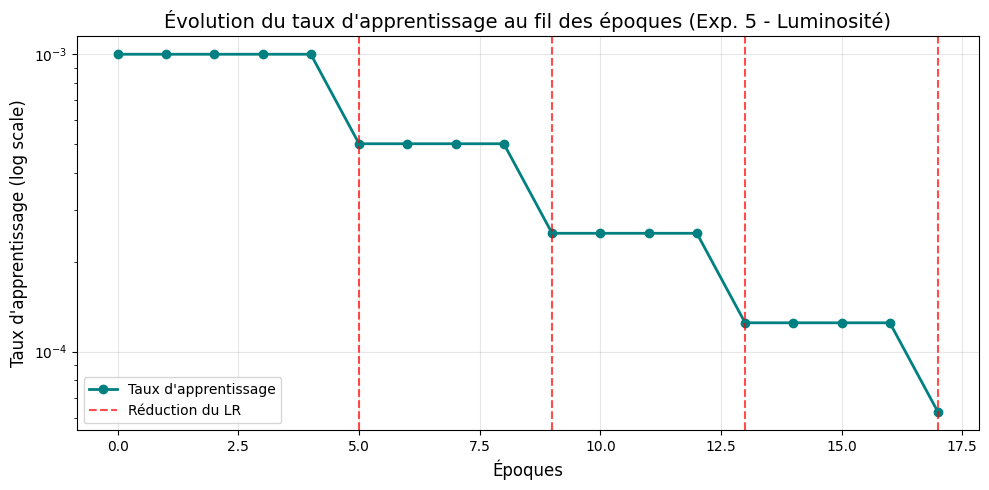

In [15]:
import matplotlib.pyplot as plt

# On extrait la liste des valeurs du learning rate au fil des époques
lr_history = history_exp5.history['learning_rate']

plt.figure(figsize=(10, 5))

# Tracé de la courbe
plt.plot(lr_history, marker='o', color='teal', linewidth=2, label="Taux d'apprentissage")

# Boucle pour détecter à quelles époques le LR a diminué et tracer les lignes verticales rouges
label_added = False
for epoch in range(1, len(lr_history)):
    if lr_history[epoch] < lr_history[epoch - 1]:
        # On ajoute le label une seule fois pour ne pas surcharger la légende
        if not label_added:
            plt.axvline(x=epoch, color='red', linestyle='--', alpha=0.7, label='Réduction du LR')
            label_added = True
        else:
            plt.axvline(x=epoch, color='red', linestyle='--', alpha=0.7)

# Utilisation d'une échelle logarithmique pour l'axe Y (comme demandé dans l'énoncé)
plt.yscale('log')

plt.title("Évolution du taux d'apprentissage au fil des époques (Exp. 5 - Luminosité)", fontsize=14)
plt.xlabel("Époques", fontsize=12)
plt.ylabel("Taux d'apprentissage (log scale)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ce graphique illustre l'action du callback ReduceLROnPlateau. L'axe Y étant logarithmique , on visualise clairement les "marches" à chaque fois que la perte de validation a stagné (marquées par les lignes rouges ). On observe par exemple que le modèle a eu besoin de réduire son taux dès l'époques 5, 9, 13 et 17, ce qui lui n’a pas beaucoup aidé à la fin, mais pour une raison différente.